In [2]:
import numpy as np
from scipy.stats import chisquare
import math
import matplotlib.pyplot as plt

Offered Traffic (A) : 8.0 Erlang
Chi-squared Stat    : 15.5057
P-value             : 0.1146826
Result: The Metropolis-Hastings sample matches the target distribution (Fail to reject H0).


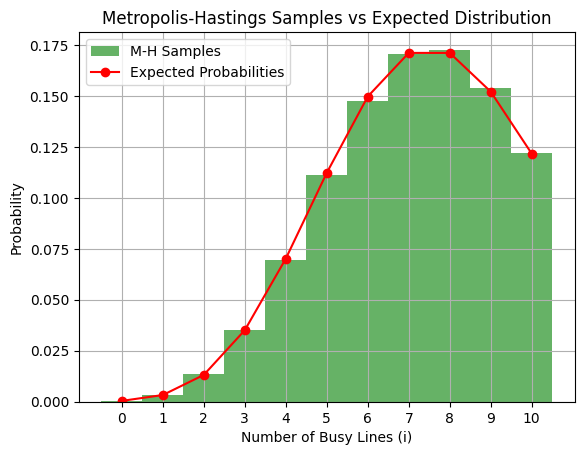

In [ ]:
import numpy as np
import math
from scipy.stats import chisquare

np.random.seed(42)

m = 10
mean_service = 8.0
mean_interarrival = 1.0
num_customers = 10000
num_runs = 10

A = (1.0 / mean_interarrival) * mean_service 

def f(x, A, m):
    if 0 <= x <= m:
        return (A**x) / math.factorial(x)
    return 0.0

def g(y, x):
    """
    Proposal distribution g(y | x).
    The probability of proposing state 'y' given current state 'x'.
    For a symmetric random walk of +1 or -1, the probability is 0.5.
    """
    if y == x + 1 or y == x - 1:
        return 0.5
    return 0.0

def metropolis_hastings_erlang(m, A, num_samples, burn_in=2000, thinning=20):
    total_steps = burn_in + (num_samples * thinning)
    samples = np.zeros(num_samples, dtype=int)
    
    x = 0  
    
    sample_idx = 0
    for step in range(total_steps):
        step_direction = np.random.choice([-1, 1])
        y = x + step_direction
        
        f_x = f(x, A, m)
        f_y = f(y, A, m)
        
        g_y_given_x = g(y, x)
        g_x_given_y = g(x, y)
        
        if f_x > 0 and g_y_given_x > 0:
            acceptance_ratio = (f_y * g_x_given_y) / (f_x * g_y_given_x)
            acceptance_prob = min(1.0, acceptance_ratio)
        else:
            acceptance_prob = 0.0
            
        if np.random.rand() < acceptance_prob:
            x = y
        
        if step >= burn_in and (step - burn_in) % thinning == 0:
            samples[sample_idx] = x
            sample_idx += 1
            
    return samples

total_samples = num_customers * num_runs
samples = metropolis_hastings_erlang(m, A, total_samples, burn_in=2000, thinning=1)

observed_counts = np.bincount(samples, minlength=m+1)

unnorm_probs = [f(i, A, m) for i in range(m + 1)]
norm_const = sum(unnorm_probs)
expected_probs = [p / norm_const for p in unnorm_probs]
expected_counts = np.array(expected_probs) * total_samples

chi2_stat, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts)

print(f"Offered Traffic (A) : {A} Erlang")
print(f"Chi-squared Stat    : {chi2_stat:.4f}")
print(f"P-value             : {p_value:.7f}")

if p_value > 0.05:
    print("Result: The Metropolis-Hastings sample matches the target distribution (Fail to reject H0).")
else:
    print("Result: The sample differs significantly from the target distribution (Reject H0).")


plt.hist(samples, bins=np.arange(-0.5, m+1.5, 1), density=True, alpha=0.6, color='g', label='M-H Samples')
plt.plot(range(m + 1), expected_probs, 'ro-', label='Expected Probabilities')
plt.title('Metropolis-Hastings Samples vs Expected Distribution')
plt.xlabel('Number of Busy Lines (i)')
plt.ylabel('Probability')
plt.xticks(range(m + 1))
plt.legend()
plt.grid()
plt.savefig('metropolis_hastings_erlang.png')

In [ ]:
import numpy as np
import math
from scipy.stats import chisquare
np.random.seed(42)
A1 = 4.0
A2 = 4.0
m = 10
num_samples = 10000
burn_in_steps = 2000
thinning_steps = 1


P_table = np.zeros((m + 1, m + 1))
for i in range(m + 1):
    for j in range(m + 1):
        if i + j <= m:
            P_table[i, j] = (A1**i / math.factorial(i)) * (A2**j / math.factorial(j))

expected_probs = P_table / np.sum(P_table)


gibbs_cdfs = []
for other_val in range(m + 1):
    limit = m - other_val
    if limit < 0:
        gibbs_cdfs.append(np.array([1.0])) 
        continue
    probs = np.array([(A1**k) / math.factorial(k) for k in range(limit + 1)])
    probs /= np.sum(probs)
    gibbs_cdfs.append(np.cumsum(probs))

def mh_direct_fast(num_samples, burn_in, thinning):
    total_steps = burn_in + (num_samples * thinning)
    samples = np.zeros((num_samples, 2), dtype=int)
    i, j = 0, 0
    
    moves_i = np.array([1, -1, 0, 0])
    moves_j = np.array([0, 0, 1, -1])
    step_choices = np.random.randint(0, 4, size=total_steps)
    rand_acc = np.random.rand(total_steps)
    
    sample_idx = 0
    for step in range(total_steps):
        move_idx = step_choices[step]
        prop_i = i + moves_i[move_idx]
        prop_j = j + moves_j[move_idx]
        
        if 0 <= prop_i <= m and 0 <= prop_j <= m and (prop_i + prop_j <= m):
            p_curr = P_table[i, j]
            p_prop = P_table[prop_i, prop_j]
            
            if rand_acc[step] < (p_prop / p_curr):
                i, j = prop_i, prop_j
                
        if step >= burn_in and (step - burn_in) % thinning == 0:
            samples[sample_idx, 0] = i
            samples[sample_idx, 1] = j
            sample_idx += 1
            
    return samples

def mh_coordinate_wise_fast(num_samples, burn_in, thinning):
    total_steps = burn_in + (num_samples * thinning)
    samples = np.zeros((num_samples, 2), dtype=int)
    i, j = 0, 0
    
    moves_i = np.random.choice([-1, 1], size=total_steps)
    moves_j = np.random.choice([-1, 1], size=total_steps)
    rand_acc_i = np.random.rand(total_steps)
    rand_acc_j = np.random.rand(total_steps)
    
    sample_idx = 0
    for step in range(total_steps):
        prop_i = i + moves_i[step]
        if 0 <= prop_i <= m and (prop_i + j <= m):
            if rand_acc_i[step] < (P_table[prop_i, j] / P_table[i, j]):
                i = prop_i
                
        prop_j = j + moves_j[step]
        if 0 <= prop_j <= m and (i + prop_j <= m):
            if rand_acc_j[step] < (P_table[i, prop_j] / P_table[i, j]):
                j = prop_j
                
        if step >= burn_in and (step - burn_in) % thinning == 0:
            samples[sample_idx, 0] = i
            samples[sample_idx, 1] = j
            sample_idx += 1
            
    return samples

def gibbs_sampling_fast(num_samples, burn_in, thinning):
    total_steps = burn_in + (num_samples * thinning)
    samples = np.zeros((num_samples, 2), dtype=int)
    i, j = 0, 0
    
    rand_i = np.random.rand(total_steps)
    rand_j = np.random.rand(total_steps)
    
    sample_idx = 0
    for step in range(total_steps):
        i = np.searchsorted(gibbs_cdfs[j], rand_i[step])
        j = np.searchsorted(gibbs_cdfs[i], rand_j[step])
        
        if step >= burn_in and (step - burn_in) % thinning == 0:
            samples[sample_idx, 0] = i
            samples[sample_idx, 1] = j
            sample_idx += 1
            
    return samples

def run_verification(samples, name):
    observed = np.zeros((m + 1, m + 1))
    for i, j in samples:
        observed[i, j] += 1
        
    obs_1d, exp_1d = [], []
    for i in range(m + 1):
        for j in range(m + 1):
            if expected_probs[i, j] > 0:
                obs_1d.append(observed[i, j])
                exp_1d.append(expected_probs[i, j] * len(samples))
                
    chi2_stat, p_value = chisquare(f_obs=obs_1d, f_exp=exp_1d)
    
    print(f"--- {name} ---")
    print(f"Chi-squared Stat : {chi2_stat:.4f}")
    print(f"P-value          : {p_value:.4e}")
    if p_value > 0.05:
        print("Result: Valid match to target distribution.\n")
    else:
        print("Result: Differs significantly from target distribution.\n")

print("Simulating (Fast Mode)...\n")
run_verification(mh_direct_fast(num_samples, burn_in_steps, thinning_steps), "(a) Direct M-H")
run_verification(mh_coordinate_wise_fast(num_samples, burn_in_steps, thinning_steps), "(b) Coordinate-wise M-H")
run_verification(gibbs_sampling_fast(num_samples, burn_in_steps, thinning_steps), "(c) Gibbs Sampling")

Simulating (Fast Mode)...

--- (a) Direct M-H ---
Chi-squared Stat : 245.2647
P-value          : 9.8615e-23
Result: Differs significantly from target distribution.

--- (b) Coordinate-wise M-H ---
Chi-squared Stat : 128.4207
P-value          : 4.6666e-06
Result: Differs significantly from target distribution.

--- (c) Gibbs Sampling ---
Chi-squared Stat : 69.8544
P-value          : 3.1784e-01
Result: Valid match to target distribution.



In [25]:
np.random.seed(42)
rho = 0.5
cov_matrix = np.array([[1, rho], [rho, 1]])
xi_true, gamma_true = np.random.multivariate_normal(mean=[0, 0], cov=cov_matrix)
theta_true, psi_true = np.exp(xi_true), np.exp(gamma_true)




n = 10

# Generate 10 observations from N(theta_true, psi_true).
# We use np.sqrt(psi_true) because np.random.normal takes the standard deviation (scale).
X_sample = np.random.normal(loc=theta_true, scale=np.sqrt(psi_true), size=n)

print(f"True Theta (Mean): {theta_true:.4f}")
print(f"True Psi (Variance): {psi_true:.4f}")
print(f"Generated Observations (X_i): \n{X_sample}")

True Theta (Mean): 0.6970
True Psi (Variance): 0.6070
Generated Observations (X_i): 
[1.20155177 1.88350718 0.51453192 0.51454471 1.92727785 1.29484288
 0.3311995  1.11964892 0.33591811 0.33411685]


Acceptance Rate: 0.43 (Target is usually ~0.2-0.5)

--- Results for n=10 ---
True Theta : 0.6970 | MCMC Estimated Theta : 0.8791
True Psi   : 0.6070 | MCMC Estimated Psi   : 0.5830

=== Running MCMC for n=10 ===
Acceptance Rate: 0.55 (Target is usually ~0.2-0.5)

--- Results for n=10 ---
True Theta : 0.6970 | MCMC Estimated Theta : 0.8511
True Psi   : 0.6070 | MCMC Estimated Psi   : 0.9944

=== Running MCMC for n=100 ===
Acceptance Rate: 0.16 (Target is usually ~0.2-0.5)

--- Results for n=100 ---
True Theta : 0.6970 | MCMC Estimated Theta : 0.6619
True Psi   : 0.6070 | MCMC Estimated Psi   : 0.7906

=== Running MCMC for n=1000 ===
Acceptance Rate: 0.02 (Target is usually ~0.2-0.5)

--- Results for n=1000 ---
True Theta : 0.6970 | MCMC Estimated Theta : 0.7177
True Psi   : 0.6070 | MCMC Estimated Psi   : 0.6633


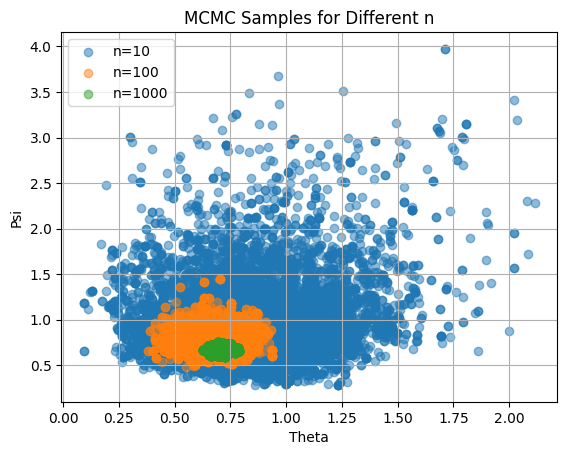

In [6]:
np.random.seed(42)

x_bar = np.mean(X_sample)
s2 = np.var(X_sample, ddof=1) if n > 1 else 0.0

# --- 2. Target Log-Posterior Distribution (from 3c) ---
def log_posterior(theta, psi, x_bar, s2, n, rho=0.5):
    # Theta and Psi must be strictly positive. 
    # Return -infinity to ensure negative proposals are always rejected.
    if theta <= 0 or psi <= 0:
        return -np.inf
        
    log_theta = np.log(theta)
    log_psi = np.log(psi)
    
    # 1. Log of the prior
    prior_term = -log_theta - log_psi - (log_theta**2 - 2*rho*log_theta*log_psi + log_psi**2) / (2 * (1 - rho**2))
    
    # 2. Log of the likelihood (using sample mean and sample variance)
    likelihood_term = -(n/2)*np.log(psi) - (n*(x_bar - theta)**2 + (n-1)*s2) / (2*psi)
    
    return prior_term + likelihood_term

# --- 3. Random Walk Metropolis-Hastings Algorithm ---
def mh_posterior_sampler(num_samples, x_bar, s2, n, init_theta, init_psi, step_size=0.5):
    samples = np.zeros((num_samples, 2))
    current_theta, current_psi = init_theta, init_psi
    current_log_prob = log_posterior(current_theta, current_psi, x_bar, s2, n)
    
    accepted = 0
    for step in range(num_samples):
        # Propose a new state via a symmetric Gaussian random walk
        prop_theta = current_theta + np.random.normal(0, step_size)
        prop_psi = current_psi + np.random.normal(0, step_size)
        
        prop_log_prob = log_posterior(prop_theta, prop_psi, x_bar, s2, n)
        
        # Calculate acceptance ratio in the log domain: log(P_prop / P_curr) = log(P_prop) - log(P_curr)
        log_acc_ratio = prop_log_prob - current_log_prob
        
        # Accept or reject
        # We compare to log(U) where U is Uniform(0,1)
        if np.log(np.random.rand()) < log_acc_ratio:
            current_theta, current_psi = prop_theta, prop_psi
            current_log_prob = prop_log_prob
            accepted += 1
            
        samples[step] = [current_theta, current_psi]
        
    print(f"Acceptance Rate: {accepted / num_samples:.2f} (Target is usually ~0.2-0.5)")
    return samples

# --- 4. Execution ---
num_mcmc_samples = 10000

# It's highly efficient to initialize the chain near the sample statistics
posterior_samples = mh_posterior_sampler(
    num_samples=num_mcmc_samples, 
    x_bar=x_bar, 
    s2=s2, 
    n=n, 
    init_theta=max(0.1, x_bar), 
    init_psi=max(0.1, s2),
    step_size=0.3 # You can tune this to get a better acceptance rate
)

# Optional: Discard the first 10% of samples as 'burn-in'
burn_in = int(0.1 * num_mcmc_samples)
valid_samples = posterior_samples[burn_in:]

estimated_theta = np.mean(valid_samples[:, 0])
estimated_psi = np.mean(valid_samples[:, 1])

print(f"\n--- Results for n={n} ---")
print(f"True Theta : {theta_true:.4f} | MCMC Estimated Theta : {estimated_theta:.4f}")
print(f"True Psi   : {psi_true:.4f} | MCMC Estimated Psi   : {estimated_psi:.4f}")


n_values = [10, 100, 1000]
for n in n_values:
    print(f"\n=== Running MCMC for n={n} ===")
    
    # Generate new data for each n
    X_sample = np.random.normal(loc=theta_true, scale=np.sqrt(psi_true), size=n)
    x_bar = np.mean(X_sample)
    s2 = np.var(X_sample, ddof=1) if n > 1 else 0.0
    
    posterior_samples = mh_posterior_sampler(
        num_samples=num_mcmc_samples, 
        x_bar=x_bar, 
        s2=s2, 
        n=n, 
        init_theta=max(0.1, x_bar), 
        init_psi=max(0.1, s2),
        step_size=0.3
    )
    
    burn_in = int(0.1 * num_mcmc_samples)
    valid_samples = posterior_samples[burn_in:]
    
    estimated_theta = np.mean(valid_samples[:, 0])
    estimated_psi = np.mean(valid_samples[:, 1])
    
    print(f"\n--- Results for n={n} ---")
    print(f"True Theta : {theta_true:.4f} | MCMC Estimated Theta : {estimated_theta:.4f}")
    print(f"True Psi   : {psi_true:.4f} | MCMC Estimated Psi   : {estimated_psi:.4f}")
    plt.scatter(valid_samples[:, 0], valid_samples[:, 1], alpha=0.5, label=f'n={n}')
    plt.xlabel('Theta')
    plt.ylabel('Psi')
    plt.title('MCMC Samples for Different n')
    plt.legend()
    plt.grid()
    




n=10 | Estimated Theta: 0.8776, Estimated Psi: 0.5759, Acc. Rate: 0.42
n=100 | Estimated Theta: 0.6352, Estimated Psi: 0.5921, Acc. Rate: 0.11
n=1000 | Estimated Theta: 0.6902, Estimated Psi: 0.6250, Acc. Rate: 0.02


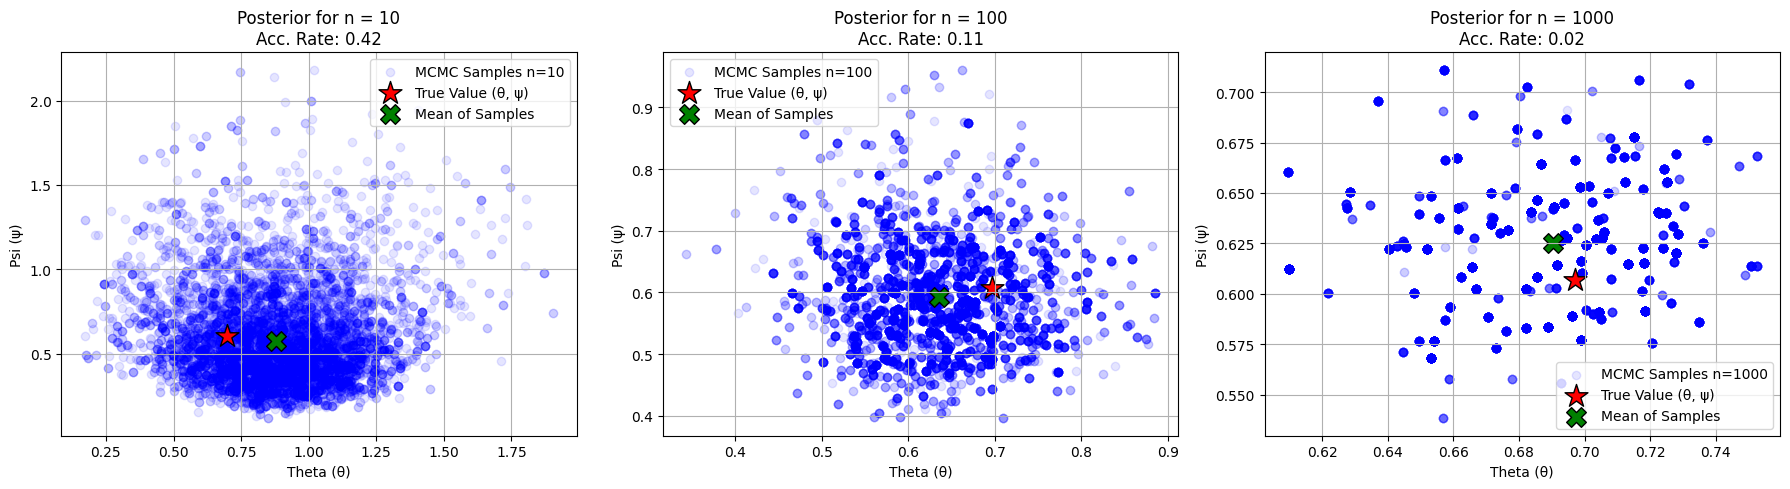

In [31]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# --- 1. True Parameters ---
rho = 0.5
cov_matrix = np.array([[1, rho], [rho, 1]])
xi_true, gamma_true = np.random.multivariate_normal(mean=[0, 0], cov=cov_matrix)
theta_true = np.exp(xi_true)
psi_true = np.exp(gamma_true)

# --- 2. Target Log-Posterior Distribution ---
def log_posterior(theta, psi, x_bar, s2, n, rho=0.5):
    if theta <= 0 or psi <= 0:
        return -np.inf
    log_theta = np.log(theta)
    log_psi = np.log(psi)
    prior_term = -log_theta - log_psi - (log_theta**2 - 2*rho*log_theta*log_psi + log_psi**2) / (2 * (1 - rho**2))
    likelihood_term = -(n/2)*np.log(psi) - (n*(x_bar - theta)**2 + (n-1)*s2) / (2*psi)
    return prior_term + likelihood_term

# --- 3. Random Walk Metropolis-Hastings Algorithm ---
def mh_posterior_sampler(num_samples, x_bar, s2, n, init_theta, init_psi, step_size=0.5):
    samples = np.zeros((num_samples, 2))
    current_theta, current_psi = init_theta, init_psi
    current_log_prob = log_posterior(current_theta, current_psi, x_bar, s2, n)
    accepted = 0
    for step in range(num_samples):
        prop_theta = current_theta + np.random.normal(0, step_size)
        prop_psi = current_psi + np.random.normal(0, step_size)
        prop_log_prob = log_posterior(prop_theta, prop_psi, x_bar, s2, n)
        log_acc_ratio = prop_log_prob - current_log_prob
        
        # Accept or reject
        if np.log(np.random.rand()) < log_acc_ratio:
            current_theta, current_psi = prop_theta, prop_psi
            current_log_prob = prop_log_prob
            accepted += 1
        samples[step] = [current_theta, current_psi]
    return samples, accepted / num_samples

# --- 4. Execution & Plotting ---
n_values = [10, 100, 1000]
num_mcmc_samples = 10000
burn_in = int(0.1 * num_mcmc_samples)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, n in enumerate(n_values):
    # Generate new data for each n
    X_sample = np.random.normal(loc=theta_true, scale=np.sqrt(psi_true), size=n)
    x_bar = np.mean(X_sample)
    s2 = np.var(X_sample, ddof=1) if n > 1 else 0.0
    
    # Use the fixed step size of 0.3 as requested in the provided code block
    step_size = 0.3
    
    posterior_samples, acc_rate = mh_posterior_sampler(
        num_samples=num_mcmc_samples, 
        x_bar=x_bar, 
        s2=s2, 
        n=n, 
        init_theta=max(0.1, x_bar), 
        init_psi=max(0.1, s2),
        step_size=step_size
    )
    
    valid_samples = posterior_samples[burn_in:]
    
    # Plotting
    ax = axes[i]
    ax.scatter(valid_samples[:, 0], valid_samples[:, 1], alpha=0.1, color='blue', label=f'MCMC Samples n={n}')
    
    # Plot the true values
    ax.scatter([theta_true], [psi_true], color='red', marker='*', s=300, edgecolor='black', label='True Value (θ, ψ)')

    # plot the mean of the samples
    mean_theta = np.mean(valid_samples[:, 0])
    mean_psi = np.mean(valid_samples[:, 1])
    ax.scatter([mean_theta], [mean_psi], color='green', marker='X', s=200, edgecolor='black', label='Mean of Samples')

    print(f"n={n} | Estimated Theta: {mean_theta:.4f}, Estimated Psi: {mean_psi:.4f}, Acc. Rate: {acc_rate:.2f}")
    
    ax.set_xlabel('Theta (θ)')
    ax.set_ylabel('Psi (ψ)')
    ax.set_title(f'Posterior for n = {n}\nAcc. Rate: {acc_rate:.2f}')
    ax.legend()
    ax.grid(True)




plt.tight_layout()
# plt.savefig('mcmc_subplots_fixed_step.png')